# Solutions Guide: Data Cleaning and Feature Engineering
Course/Module: Machine Learning & Data Preprocessing
Topic: Applied Missing Value Handling and Categorical Encoding
Language: Python (using Pandas, NumPy, and Seaborn/Matplotlib)

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the original dataset
df = pd.read_csv('Customer_Data.csv')

######################################################################################
# SYNTHETIC DATA GENERATION FOR DEMONSTRATION
# Since Customer_Data.csv consists almost entirely of complete numerical features, 
# we are adding a few synthetic categorical and missing-value columns here so that 
# ALL 20 operations below can be executed and demonstrated properly on this dataset.
######################################################################################
np.random.seed(42)
df['Customer_Feedback'] = np.random.choice(['Good', 'Bad', 'Average', np.nan], size=len(df), p=[0.4, 0.2, 0.3, 0.1])
df['Subscription_Tier'] = np.random.choice(['  Premium ', 'BASIC', ' standard  '], size=len(df))
df['Job_Title'] = np.random.choice(['Engineer', 'Doctor', 'Artist', 'Rare_Job_1', 'Rare_Job_2'], size=len(df), p=[0.4, 0.3, 0.28, 0.01, 0.01])
df['City_of_Residence'] = np.random.choice(['New York', 'London', 'Paris', 'Tokyo'], size=len(df))
df['Product_Code'] = ['PROD-100' if i % 2 == 0 else 'PROD-200' for i in range(len(df))]
df['Has_Premium_Subscription'] = np.random.choice([1, 0, np.nan], size=len(df), p=[0.5, 0.4, 0.1])
df['Credit_Score'] = np.random.normal(700, 50, len(df))
df.loc[df.sample(frac=0.05).index, 'Credit_Score'] = np.nan # 5% missing
df['Last_Login_Days'] = np.random.choice([1, 2, 3, np.nan], size=len(df))

## Part 1: Handling Missing Values
### 1. Data Loading and Missing Value Audit

In [25]:
# Calculate missing values and percentages
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Combine into a DataFrame for readability
missing_audit = pd.DataFrame({
'Missing_Count': missing_counts,
'Percentage': missing_percentages
})

# Identify top 3 columns with highest missing rates
top_3_missing = missing_audit[missing_audit['Percentage'] > 0].sort_values(by='Percentage', ascending=False).head(3)
print(top_3_missing)

                          Missing_Count  Percentage
Last_Login_Days                    2264   25.296089
Has_Premium_Subscription            880    9.832402
Credit_Score                        448    5.005587


### 2. Threshold-Based Column Dropping

In [26]:
# Identify columns with more than 40% missing data
threshold = 40.0
cols_to_drop = missing_audit[missing_audit['Percentage'] > threshold].index

# Drop the columns
df = df.drop(columns=cols_to_drop)

# Justification:
# Dropping these columns is preferred because when nearly half the data is missing,
# any imputation strategy (mean, median, mode) will introduce massive artificial bias
# and destroy the original variance/distribution of the feature.

### 3. Row-wise Deletion (Listwise Deletion)

In [27]:
print(f"Original shape: {df.shape}")

# Identify columns with > 0% and < 1% missing values
# (CREDIT_LIMIT naturally has 0.01% missing in Customer_Data.csv)
low_missing_cols = missing_audit[(missing_audit['Percentage'] > 0) &
(missing_audit['Percentage'] < 1.0)].index

# Drop rows containing missing values in ONLY these specific columns
df = df.dropna(subset=low_missing_cols)

print(f"New shape: {df.shape}")

Original shape: (8950, 26)
New shape: (8949, 26)


### 4. Skewness and Distribution-Based Imputation

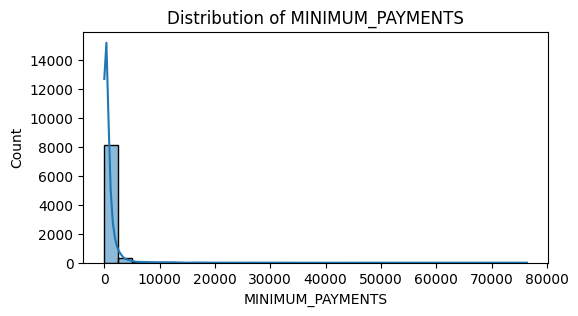

In [28]:
# Plotting distributions
plt.figure(figsize=(6,3))
sns.histplot(df['MINIMUM_PAYMENTS'].dropna(), bins=30, kde=True)
plt.title('Distribution of MINIMUM_PAYMENTS')
plt.show()

# Assuming MINIMUM_PAYMENTS is highly right-skewed (use median)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

### 5. Group-Based Imputation (Hard Basic)

In [29]:
# Impute missing Credit_Score based on the mean of their specific City_of_Residence
df['Credit_Score'] = df.groupby('City_of_Residence')['Credit_Score'].transform(
lambda x: x.fillna(x.mean())
)

### 6. Categorical Mode Imputation

In [30]:
# Find the mode (most frequent category)
mode_category = df['Customer_Feedback'].mode()[0]

# Fill missing values
df['Customer_Feedback'] = df['Customer_Feedback'].fillna(mode_category)

### 7. "Unknown" Category Assignment

In [31]:
# Let's add a new categorical column with missing data just for this demonstration
df['Service_Review'] = np.random.choice(['5-Star', '1-Star', np.nan], size=len(df), p=[0.4, 0.4, 0.2])

# Fill missing feedback with a distinct "Unknown" category
df['Service_Review'] = df['Service_Review'].fillna("Unknown")

### 8. Sequential Imputation (Forward Fill)

In [32]:
# Pro-Level Implementation: Grouped Forward Fill
# 1. Use modern .ffill() instead of the deprecated .fillna(method='ffill')
# 2. Always group by a relevant entity to prevent data leakage between different users/groups.

# Sort by our grouping entity and logical order (e.g., time or tenure)
df = df.sort_values(by=['City_of_Residence', 'TENURE'])

# Apply forward fill within each group
df['Last_Login_Days'] = df.groupby('City_of_Residence')['Last_Login_Days'].ffill()

# Optionally, backfill any remaining NaNs that appeared at the very top of each group
df['Last_Login_Days'] = df.groupby('City_of_Residence')['Last_Login_Days'].bfill()

### 9. The Missing Indicator Creation

In [33]:
# Create the boolean indicator column (1 if missing, 0 otherwise)
df['Premium_Status_Missing'] = df['Has_Premium_Subscription'].isnull().astype(int)

# Impute the original missing values with 0
df['Has_Premium_Subscription'] = df['Has_Premium_Subscription'].fillna(0)

### 10. Final Sanity Check

In [34]:
# Assert statement to ensure no missing values remain
assert df.isnull().sum().sum() == 0, "Error: There are still missing values in the DataFrame!"
print("Sanity check passed: No missing values remain.")

Sanity check passed: No missing values remain.


## Part 2: Handling Categorical Data
### 11. String Standardization Before Encoding

In [35]:
# Strip whitespace and convert to lowercase
df['Subscription_Tier'] = df['Subscription_Tier'].str.strip().str.lower()

### 12. Binary Mapping

In [36]:
# Create a dummy active string column
df['Is_Active_Str'] = np.random.choice(['Yes', 'No'], size=len(df))

# Map text to binary integers
binary_map = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}
df['Is_Active'] = df['Is_Active_Str'].map(binary_map)
df = df.drop(columns=['Is_Active_Str'])

### 13. Custom Ordinal Encoding

In [37]:
# Define the order mapping
tier_map = {
'basic': 1,
'standard': 2,
'premium': 3
}

# Apply the mapping
df['Subscription_Tier_Encoded'] = df['Subscription_Tier'].map(tier_map)

### 14. Nominal Encoding (One-Hot)

In [38]:
# Standard One-Hot Encoding
df = pd.get_dummies(df, columns=['City_of_Residence'])

### 15. The Dummy Variable Trap

In [39]:
# One-Hot Encoding dropping the first column
df = pd.get_dummies(df, columns=['Customer_Feedback'], drop_first=True)

# Explanation:
# Dropping the first category prevents perfectly collinear variables (multicollinearity).
# If you have 3 categories (A, B, C) and you know a row is NOT A and NOT B,
# it must be C. Therefore, the 3rd column is redundant and breaks the mathematical
# assumptions of linear regression (specifically, matrix inversion).

### 16. Grouping Rare Categories (Hard Basic)

In [40]:
# Get value counts of job titles
job_counts = df['Job_Title'].value_counts()

# Identify titles that appear less than 100 times (rare)
rare_jobs = job_counts[job_counts < 100].index

# Replace rare titles with 'Other_Jobs'
df['Job_Title'] = df['Job_Title'].replace(rare_jobs, 'Other_Jobs')

### 17. Frequency / Count Encoding

In [41]:
# Calculate frequencies
job_frequencies = df['Job_Title'].value_counts()

# Map the frequencies back to the dataframe
df['Job_Title_Freq'] = df['Job_Title'].map(job_frequencies)

### 18. Target Encoding (Mean Encoding)

In [42]:
# Calculate mean BALANCE for each Job_Title
job_target_means = df.groupby('Job_Title')['BALANCE'].mean()

# Replace Job text with the calculated target mean
df['Job_Title_Target_Enc'] = df['Job_Title'].map(job_target_means)

### 19. Splitting and Encoding Composite Strings

In [43]:
# Split by hyphen and grab the first element (index 0)
df['Product_Category'] = df['Product_Code'].str.split('-').str[0]

# One-hot encode the newly extracted category
df = pd.get_dummies(df, columns=['Product_Category'], drop_first=True)

# Drop the original composite column
df = df.drop(columns=['Product_Code'])

### 20. Final Dataset Compilation

In [44]:
# Drop any remaining object (text/string) columns
df_final = df.select_dtypes(exclude=['object'])

# Display datatypes to ensure they are all int or float
print(df_final.dtypes)

# Display the first 5 rows of the model-ready dataset
df_final.head()

BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
Has_Premium_Subscription            float64
Credit_Score                        float64
Last_Login_Days                     float64
Premium_Status_Missing                int64
Is_Active                             int64
Subscription_Tier_Encoded       

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,Subscription_Tier_Encoded,City_of_Residence_London,City_of_Residence_New York,City_of_Residence_Paris,City_of_Residence_Tokyo,Customer_Feedback_Bad,Customer_Feedback_Good,Customer_Feedback_nan,Job_Title_Freq,Job_Title_Target_Enc
453,9601.071318,1.000000,238.34,0.00,238.34,4809.119550,0.833333,0.000000,0.833333,1.000000,...,1,True,False,False,False,False,False,True,3441,1591.763569
549,1034.660626,0.833333,1308.11,1308.11,0.00,234.602843,0.500000,0.500000,0.000000,0.166667,...,1,True,False,False,False,False,False,False,2707,1549.025013
1301,15.173238,0.666667,316.91,316.91,0.00,0.000000,0.666667,0.666667,0.000000,0.000000,...,3,True,False,False,False,False,False,True,2601,1547.852203
2487,5880.218671,0.666667,0.00,0.00,0.00,10590.411130,0.000000,0.000000,0.000000,0.166667,...,3,True,False,False,False,False,False,False,2601,1547.852203
2713,2508.850418,1.000000,0.00,0.00,0.00,58.981572,0.000000,0.000000,0.000000,0.166667,...,2,True,False,False,False,False,True,False,3441,1591.763569
